In [1]:
import pandas as pd

In [2]:
df = "games.csv"
games = pd.read_csv(df)

In [3]:
games.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [4]:
games = games.dropna()

In [5]:
games.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [6]:
games.Year.value_counts()

2009.0    1431
2008.0    1428
2010.0    1257
2007.0    1201
2011.0    1136
2006.0    1008
2005.0     936
2002.0     829
2003.0     775
2004.0     744
2012.0     655
2015.0     614
2014.0     580
2013.0     546
2001.0     482
1998.0     379
2000.0     349
2016.0     342
1999.0     338
1997.0     289
1996.0     263
1995.0     219
1994.0     121
1993.0      60
1981.0      46
1992.0      43
1991.0      41
1982.0      36
1986.0      21
1983.0      17
1989.0      17
1990.0      16
1987.0      16
1988.0      15
1985.0      14
1984.0      14
1980.0       9
2017.0       3
2020.0       1
Name: Year, dtype: int64

In [7]:
games.Platform.value_counts(normalize=True)

DS      0.130808
PS2     0.130563
PS3     0.080044
Wii     0.079185
X360    0.075747
PSP     0.073476
PS      0.072985
PC      0.057578
XB      0.049291
GBA     0.048247
GC      0.033270
3DS     0.030630
PSV     0.025167
PS4     0.020625
N64     0.019397
SNES    0.014671
XOne    0.013075
SAT     0.010619
WiiU    0.008778
2600    0.007120
NES     0.006016
GB      0.005954
DC      0.003192
GEN     0.001657
NG      0.000737
SCD     0.000368
WS      0.000368
3DO     0.000184
TG16    0.000123
GG      0.000061
PCFX    0.000061
Name: Platform, dtype: float64

In [8]:
games.Publisher.value_counts()

Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
                                ... 
Sold Out                           1
Enjoy Gaming ltd.                  1
Lighthouse Interactive             1
Just Flight                        1
Palcom                             1
Name: Publisher, Length: 576, dtype: int64

In [12]:
games[games['Publisher'] == 'Nintendo'][['Global_Sales']].agg(['mean', 'median', 'std'])

,Global_Sales
mean,2.563836
median,0.920000
std,5.676925


In [13]:
games[games['Publisher'] == 'Nintendo'][['Other_Sales']].agg(['mean', 'median', 'std'])

,Other_Sales
mean,0.136767
median,0.030000
std,0.464170


In [14]:
games[games['Publisher'] == 'Nintendo'][['JP_Sales']].agg(['mean', 'median', 'std'])

,JP_Sales
mean,0.653721
median,0.280000
std,1.063110


In [15]:
games[games['Publisher'] == 'Nintendo'][['EU_Sales']].agg(['mean', 'median', 'std'])

,EU_Sales
mean,0.601006
median,0.120000
std,1.743953


In [16]:
games[games['Publisher'] == 'Nintendo'][['NA_Sales']].agg(['mean', 'median', 'std'])

,NA_Sales
mean,1.172055
median,0.375000
std,2.989913


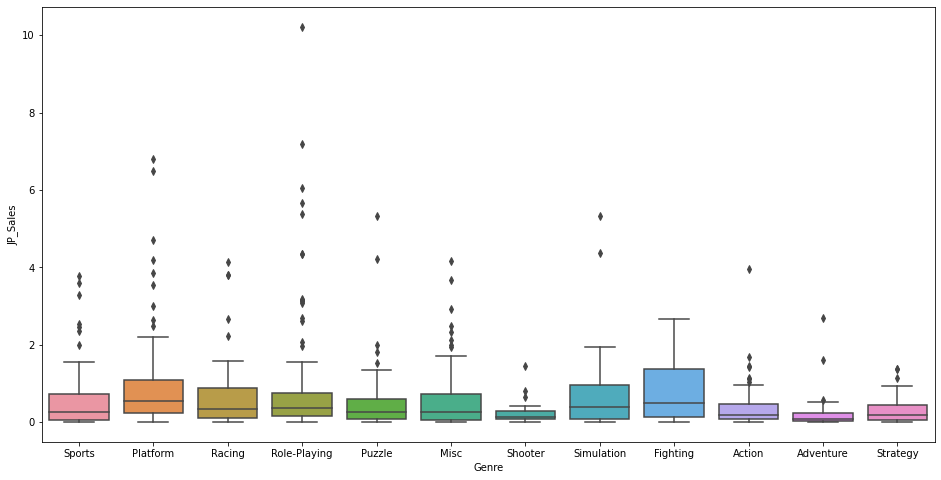

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Фильтруем данные только для Nintendo
nintendo_games = games[games["Publisher"] == "Nintendo"]

# Настройка размера графика
plt.figure(figsize=(16, 8))

# Построение barplot
sns.boxplot(x=nintendo_games["Genre"], y=nintendo_games["JP_Sales"])


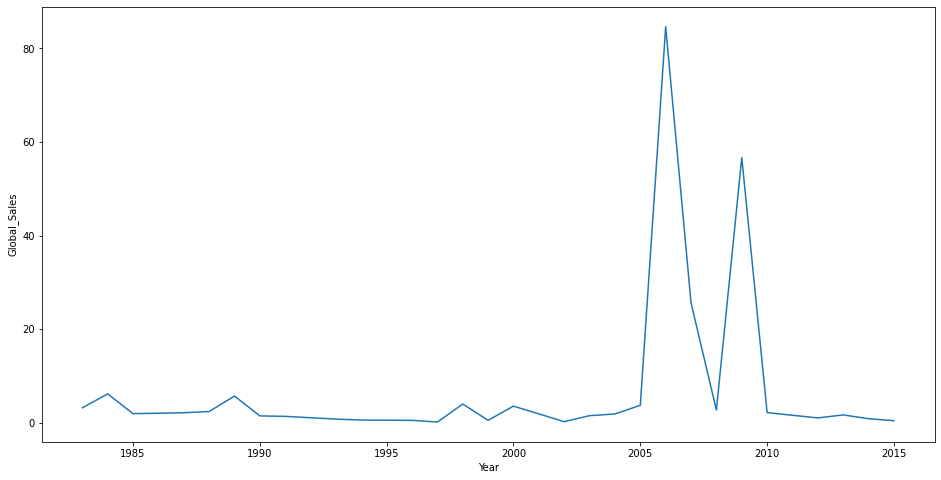

In [26]:
# Фильтруем игры Nintendo нужных жанров
selected_genres = ["Sports"]
nintendo_filtered = games[
    (games["Publisher"] == "Nintendo") & 
    (games["Genre"].isin(selected_genres))
]
# Группируем по году и жанру, суммируем продажи
sales_trend = nintendo_filtered.groupby(["Year", "Genre"])["Global_Sales"].sum().reset_index()

# Настраиваем размер графика
plt.figure(figsize=(16, 8))

# Строим линейный график
sns.lineplot(data=sales_trend, x="Year", y="Global_Sales")